In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from ibm_hardware import (
    get_ibm_service,
    get_backend,
    run_bb84_hardware_case_set
)

In [2]:
service = get_ibm_service()

backend = get_backend(
    service=service,
    backend_name=None,
    min_num_qubits=1
)

print("Selected backend:", backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-30 12:29:14,879: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:15,330: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:19,136: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


In [3]:
df = run_bb84_hardware_case_set(
    backend_name=None,
    shots=1000,
    optimization_level=1
)

df

qiskit_runtime_service.__init__:WARNING:2026-06-30 12:29:27,273: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:27,741: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:31,500: Using instance: open-instance, plan: open


Submitted IBM Quantum job: d91milr57qjs73b6lsd0
Backend: ibm_kingston


qiskit_runtime_service.__init__:WARNING:2026-06-30 12:29:50,987: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:51,466: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 12:29:55,430: Using instance: open-instance, plan: open


Submitted IBM Quantum job: d91mirvqq29s738o08jg
Backend: ibm_kingston


qiskit_runtime_service.__init__:WARNING:2026-06-30 12:30:12,349: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 12:30:12,856: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 12:30:16,469: Using instance: open-instance, plan: open


Submitted IBM Quantum job: d91mj17qq29s738o090g
Backend: ibm_kingston


qiskit_runtime_service.__init__:WARNING:2026-06-30 12:30:31,153: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 12:30:31,663: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 12:30:35,493: Using instance: open-instance, plan: open


Submitted IBM Quantum job: d91mj5r57qjs73b6ltgg
Backend: ibm_kingston


,case,alice_bit,alice_basis,bob_basis,same_basis,backend_name,job_id,shots,count_0,count_1,prob_0,prob_1
0,same_basis_Z_bit_0,0,Z,Z,True,ibm_kingston,d91milr57qjs73b6lsd0,1000,975,25,0.975,0.025
1,same_basis_X_bit_0,0,X,X,True,ibm_kingston,d91mirvqq29s738o08jg,1000,973,27,0.973,0.027
2,different_basis_Z_to_X,0,Z,X,False,ibm_kingston,d91mj17qq29s738o090g,1000,498,502,0.498,0.502
3,different_basis_X_to_Z,0,X,Z,False,ibm_kingston,d91mj5r57qjs73b6ltgg,1000,512,488,0.512,0.488


In [4]:
df.to_csv("../results/ibm_hardware_results.csv", index=False)

print("Saved results to ../results/ibm_hardware_results.csv")

Saved results to ../results/ibm_hardware_results.csv


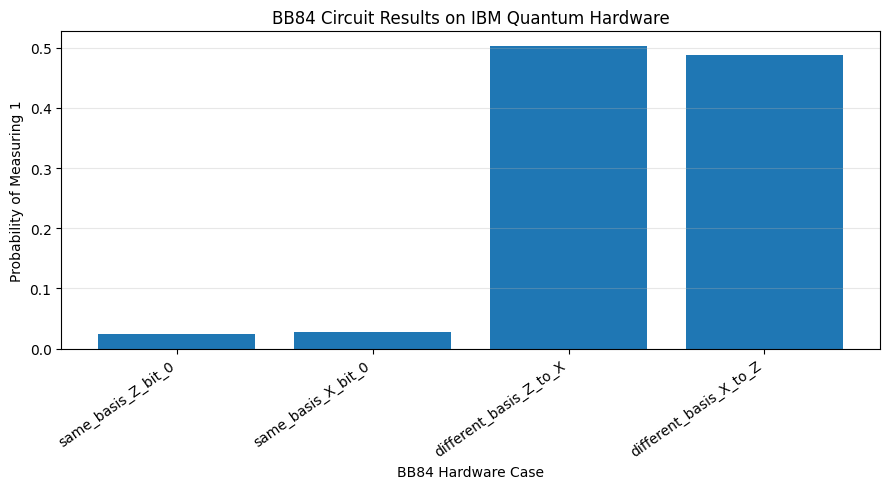

In [5]:
plt.figure(figsize=(9, 5))

plt.bar(
    df["case"],
    df["prob_1"]
)

plt.xlabel("BB84 Hardware Case")
plt.ylabel("Probability of Measuring 1")
plt.title("BB84 Circuit Results on IBM Quantum Hardware")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/ibm_hardware_comparison.png", dpi=300)
plt.show()

# IBM Quantum Hardware Demo

This notebook runs selected BB84 circuit cases on IBM Quantum hardware.

Earlier versions compared ideal and noisy simulations. This version adds a small hardware run to show how real quantum devices differ from ideal circuit behavior.

The experiment runs four BB84 cases:

1. Same-basis Z measurement
2. Same-basis X measurement
3. Different-basis Z-to-X measurement
4. Different-basis X-to-Z measurement

Same-basis cases should mostly recover Alice's bit, while different-basis cases should be closer to random. Real hardware noise may cause deviations from the ideal result.